---
## 1. Load and Merge Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# Consistent plot styling for publication-ready figures
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
sns.set_palette('husl')

In [2]:
# Load product metadata; the primary table with one row per product SKU
products = pd.read_csv('product_info.csv')
print(f'product_info shape: {products.shape}')
print(f'Columns: {list(products.columns)}')

product_info shape: (8494, 27)
Columns: ['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count', 'rating', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price']


In [3]:
# Load all five review files and stack them into a single dataframe.
# The files are split by product_id range
# gives us the full review corpus without deduplication risk at this stage.
review_files = [
    'reviews_0-250.csv',
    'reviews_250-500.csv',
    'reviews_500-750.csv',
    'reviews_750-1250.csv',
    'reviews_1250-end.csv'
]

review_chunks = []
for path in review_files:
    chunk = pd.read_csv(path, low_memory=False)
    print(f'  Loaded {path}: {chunk.shape}')
    review_chunks.append(chunk)

reviews = pd.concat(review_chunks, ignore_index=True)
print(f'\nCombined reviews shape: {reviews.shape}')
print(f'Columns: {list(reviews.columns)}')

  Loaded reviews_0-250.csv: (602130, 19)
  Loaded reviews_250-500.csv: (206725, 19)
  Loaded reviews_500-750.csv: (116262, 19)
  Loaded reviews_750-1250.csv: (119317, 19)
  Loaded reviews_1250-end.csv: (49977, 19)

Combined reviews shape: (1094411, 19)
Columns: ['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']


---
## 2. Exploratory Data Analysis

In [6]:
print('=== PRODUCT INFO ===')
print(f'Shape: {products.shape}')
print(f'\nMissing values per column:')
print(products.isnull().sum()[products.isnull().sum() > 0])
print(f'\nDuplicate product_id rows: {products.duplicated(subset="product_id").sum()}')
print(f'Unique brands: {products["brand_name"].nunique()}')
print(f'\nSummary statistics:')
products[['loves_count','rating','reviews','price_usd']].describe().round(2)

=== PRODUCT INFO ===
Shape: (8494, 27)

Missing values per column:
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
value_price_usd       8043
sale_price_usd        8224
highlights            2207
secondary_category       8
tertiary_category      990
child_max_price       5740
child_min_price       5740
dtype: int64

Duplicate product_id rows: 0
Unique brands: 304

Summary statistics:


,loves_count,rating,reviews,price_usd
count,8494.00,8216.00,8216.00,8494.00
mean,29179.57,4.19,448.55,51.66
std,66092.12,0.52,1101.98,53.67
min,0.00,1.00,1.00,3.00
25%,3758.00,3.98,26.00,25.00
50%,9880.00,4.29,122.00,35.00
75%,26841.25,4.53,418.00,58.00
max,1401068.00,5.00,21281.00,1900.00


In [7]:
print('=== REVIEWS ===')
print(f'Shape: {reviews.shape}')
print(f'\nMissing values per column:')
print(reviews.isnull().sum()[reviews.isnull().sum() > 0])
print(f'\nDuplicate rows: {reviews.duplicated().sum()}')
print(f'\nSummary statistics:')
reviews[['rating','helpfulness','total_feedback_count']].describe().round(2)

=== REVIEWS ===
Shape: (1094411, 19)

Missing values per column:
is_recommended    167988
helpfulness       561592
review_text         1444
review_title      310654
skin_tone         170539
eye_color         209628
skin_type         111557
hair_color        226768
dtype: int64

Duplicate rows: 0

Summary statistics:


,rating,helpfulness,total_feedback_count
count,1094411.00,532819.00,1094411.00
mean,4.30,0.77,4.18
std,1.15,0.32,22.72
min,1.00,0.00,0.00
25%,4.00,0.65,0.00
50%,5.00,0.93,0.00
75%,5.00,1.00,3.00
max,5.00,1.00,5464.00


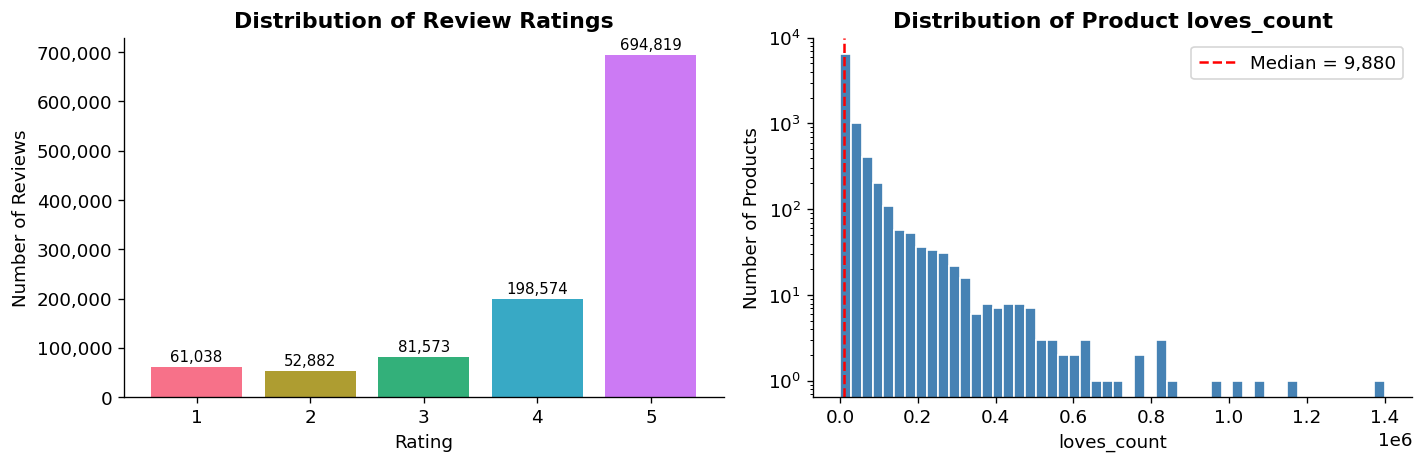

In [18]:
# ── Visualization 1: Distribution of review ratings ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

review_counts = reviews['rating'].value_counts().sort_index()
axes[0].bar(review_counts.index, review_counts.values, color=sns.color_palette('husl', 5))
axes[0].set_title('Distribution of Review Ratings', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(axes[0].patches, review_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# ── Visualization 2: Distribution of loves_count ─────────────────────────────
axes[1].hist(products['loves_count'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Product loves_count', fontweight='bold')
axes[1].set_xlabel('loves_count')
axes[1].set_ylabel('Number of Products')
axes[1].set_yscale('log')
axes[1].axvline(products['loves_count'].median(), color='red', linestyle='--',
                label=f'Median = {int(products["loves_count"].median()):,}')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_rating_loves_distributions.png', bbox_inches='tight')
plt.show()

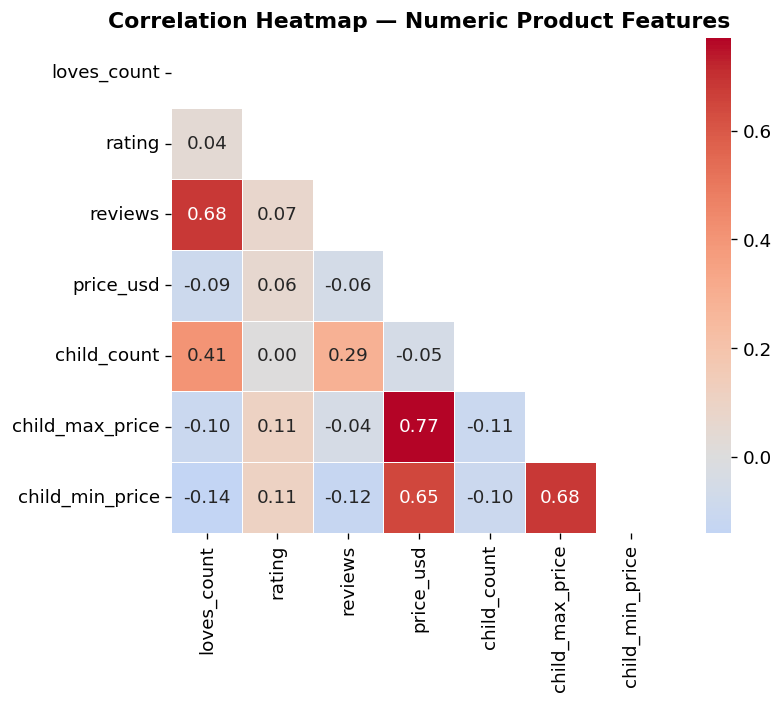

In [19]:
# ── Visualization 4: Correlation heatmap of numeric features ─────────────────
num_cols = ['loves_count','rating','reviews','price_usd',
            'child_count','child_max_price','child_min_price']
corr = products[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Numeric Product Features', fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 3. Data Cleaning

In [20]:
# ── 3a. Remove duplicate products ────────────────────────────────────────────
before = len(products)
products = products.drop_duplicates(subset='product_id', keep='first').copy()
print(f'Dropped {before - len(products)} duplicate product rows. Remaining: {len(products)}')

Dropped 0 duplicate product rows. Remaining: 8494


In [21]:
# ── 3b. Extract numeric size from free-text 'size' column ────────────────────
def extract_numeric_size(text):
    if pd.isna(text):
        return np.nan
    # Match a valid float: digits optionally followed by a single decimal + more digits.
    # Using \d+(?:\.\d+)? avoids greedily matching strings like "4.4." as a float.
    match = re.search(r'(\d+(?:\.\d+)?)', str(text))
    return float(match.group(1)) if match else np.nan

products['numeric_size'] = products['size'].apply(extract_numeric_size)
print(f'Numeric size extracted. Non-null: {products["numeric_size"].notna().sum()} / {len(products)}')
print(products['numeric_size'].describe().round(2))

Numeric size extracted. Non-null: 6850 / 8494
count    6850.00
mean        4.74
std        12.74
min         0.00
25%         0.50
50%         1.70
75%         5.00
max       400.00
Name: numeric_size, dtype: float64


In [22]:
# ── 3c. Remove duplicate reviews ─────────────────────────────────────────────
before_rev = len(reviews)
reviews = reviews.drop_duplicates().copy()
reviews = reviews.drop_duplicates(subset=['author_id','product_id'], keep='first').copy()
print(f'Dropped {before_rev - len(reviews)} duplicate review rows. Remaining: {len(reviews)}')

Dropped 0 duplicate review rows. Remaining: 1088886


In [23]:
# ── 3d. Clean review text ─────────────────────────────────────────────────────
reviews['review_text'] = reviews['review_text'].fillna('').str.strip()
reviews['review_text'] = reviews['review_text'].str.replace(r'\s+', ' ', regex=True)
reviews['text_length'] = reviews['review_text'].str.len()
print('Review text cleaned. Sample text_length stats:')
print(reviews['text_length'].describe().round(1))

Review text cleaned. Sample text_length stats:
count    1088886.0
mean         320.0
std          231.3
min            0.0
25%          171.0
50%          262.0
75%          401.0
max         6448.0
Name: text_length, dtype: float64


In [24]:
# ── 3e. Handle missing numeric values in products ─────────────────────────────
products['sale_price_usd'] = products['sale_price_usd'].fillna(0)
products['value_price_usd'] = products['value_price_usd'].fillna(0)
products['child_max_price'] = products['child_max_price'].fillna(products['price_usd'])
products['child_min_price'] = products['child_min_price'].fillna(products['price_usd'])

# Derive a boolean discount indicator — useful feature independent of missing prices
products['is_on_sale'] = (products['sale_price_usd'] > 0).astype(int)
products['price_range'] = products['child_max_price'] - products['child_min_price']

print('Price columns cleaned. is_on_sale distribution:')
print(products['is_on_sale'].value_counts())

Price columns cleaned. is_on_sale distribution:
is_on_sale
0    8224
1     270
Name: count, dtype: int64


---
## 4. Feature Engineering

In [25]:
# ── 4a. Aggregate review-level features per product ───────────────────────────
review_agg = reviews.groupby('product_id').agg(
    avg_review_score   = ('rating', 'mean'),
    total_review_count = ('rating', 'count'),
    avg_text_length    = ('text_length', 'mean'),
    pct_five_star      = ('rating', lambda x: (x == 5).mean()),
    verified_ratio     = ('is_recommended', 'mean'),   # NaN means no recommendation data
    avg_helpfulness    = ('helpfulness', 'mean')
).reset_index()

print('Review aggregation shape:', review_agg.shape)
print(review_agg.head(3))

Review aggregation shape: (2351, 7)
  product_id  avg_review_score  total_review_count  avg_text_length  \
0    P107306          4.028226                 248       293.451613   
1    P114902          4.415655                1482       389.751012   
2     P12045          4.442515                1670       259.203593   

   pct_five_star  verified_ratio  avg_helpfulness  
0       0.564516        0.708861         0.787000  
1       0.686235        0.871314         0.827428  
2       0.686826        0.871668         0.780976  


In [26]:
# ── 4b. Merge aggregated review features onto product data ────────────────────
# Left join preserves all products
# # those with zero reviews get NaN review features
df = products.merge(review_agg, on='product_id', how='left')
print(f'Merged dataset shape: {df.shape}')

# Products that had no reviews at all
no_reviews = df['total_review_count'].isna().sum()
print(f'Products with no reviews in review files: {no_reviews}')

Merged dataset shape: (8494, 36)
Products with no reviews in review files: 6143


In [27]:
# ── 4c. Derived ratio features ────────────────────────────────────────────────
df['review_to_rating_ratio'] = df['reviews'] / (df['rating'].replace(0, np.nan))
df['engagement_score'] = df['total_review_count'] / (df['price_usd'].replace(0, 1))

print('Derived features created.')
print(df[['review_to_rating_ratio','engagement_score']].describe().round(3))

Derived features created.
       review_to_rating_ratio  engagement_score
count                8216.000          2351.000
mean                  105.356            16.122
std                   259.483            51.674
min                     0.200             0.002
25%                     6.641             0.737
50%                    29.316             3.750
75%                    98.281            12.775
max                  5151.537          1278.333


In [28]:
# ── 4d. Binary product-level flags already in the data ────────────────────────
flag_cols = ['limited_edition','new','online_only','out_of_stock','sephora_exclusive']
print(df[flag_cols].value_counts().head(10))

limited_edition  new  online_only  out_of_stock  sephora_exclusive
0                0    0            0             0                    3932
                                                 1                    1583
                      1            0             0                    1209
                                                 1                     247
                      0            1             0                     238
                 1    0            0             0                     192
                                                 1                     144
1                0    0            0             0                     138
0                0    0            1             1                     109
                      1            1             0                      86
Name: count, dtype: int64


---
## 5. Create Target Variable

In [29]:
# Median split on loves_count.
median_loves = df['loves_count'].median()
df['is_popular'] = (df['loves_count'] > median_loves).astype(int)

print(f'Median loves_count: {median_loves:,.0f}')
print('\nClass balance:')
print(df['is_popular'].value_counts())
print(df['is_popular'].value_counts(normalize=True).round(3))

Median loves_count: 9,880

Class balance:
is_popular
0    4247
1    4247
Name: count, dtype: int64
is_popular
0    0.5
1    0.5
Name: proportion, dtype: float64


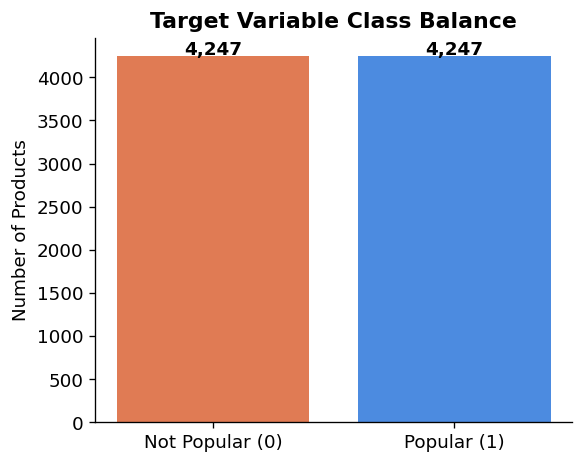

In [30]:
# ── Visualize class distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['is_popular'].value_counts()
bars = ax.bar(['Not Popular (0)', 'Popular (1)'], counts.values,
              color=['#e07b54', '#4c8be0'])
ax.set_title('Target Variable Class Balance', fontweight='bold')
ax.set_ylabel('Number of Products')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_class_balance.png', bbox_inches='tight')
plt.show()

In [31]:
# Exclude from features
LEAKAGE_COLS = ['loves_count', 'product_id', 'product_name', 'brand_id']

# Drop columns not as useful as features                 — replaced by numeric_size
DROP_COLS = LEAKAGE_COLS + [
    'variation_value', 'variation_desc', 'ingredients',
    'highlights', 'size', 'is_popular'
]

feature_df = df.drop(columns=DROP_COLS, errors='ignore')
print('Feature matrix shape (before train/test split):', feature_df.shape)
print('Columns kept:', list(feature_df.columns))

Feature matrix shape (before train/test split): (8494, 29)
Columns kept: ['brand_name', 'rating', 'reviews', 'variation_type', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price', 'numeric_size', 'is_on_sale', 'price_range', 'avg_review_score', 'total_review_count', 'avg_text_length', 'pct_five_star', 'verified_ratio', 'avg_helpfulness', 'review_to_rating_ratio', 'engagement_score']


---
## 7. Preprocessing Pipeline

In [32]:
# Separate features (X) and target (y)
X = feature_df.copy()
y = df['is_popular'].copy()

# Identify column types for the ColumnTransformer
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
for col in cat_cols.copy():
    n_unique = X[col].nunique()
    if n_unique > 200:
        print(f'  Dropping high-cardinality categorical: {col} ({n_unique} unique values)')
        X = X.drop(columns=[col])
        cat_cols.remove(col)

print(f'\nNumeric features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

  Dropping high-cardinality categorical: brand_name (304 unique values)

Numeric features (24): ['rating', 'reviews', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'child_count', 'child_max_price', 'child_min_price', 'numeric_size', 'is_on_sale', 'price_range', 'avg_review_score', 'total_review_count', 'avg_text_length', 'pct_five_star', 'verified_ratio', 'avg_helpfulness', 'review_to_rating_ratio', 'engagement_score']
Categorical features (4): ['variation_type', 'primary_category', 'secondary_category', 'tertiary_category']


In [33]:
# Build preprocessing pipelines:
#  • Numeric: median imputation (robust to skewed data) + standard scaling
#  • Categorical: constant imputation ('missing') + one-hot encoding (handle_unknown='ignore'
#    so unseen categories during test don't break prediction)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,  num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print('Preprocessing pipeline defined.')

Preprocessing pipeline defined.


---
## 8. Train / Test Split

In [34]:
# 80/20 stratified split — stratify=y ensures the class balance is preserved
# in both train and test sets, which is important for reliable evaluation.
# random_state=42 makes results reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f'Training set: {X_train.shape[0]} products ({y_train.mean():.1%} popular)')
print(f'Test set:     {X_test.shape[0]} products ({y_test.mean():.1%} popular)')

Training set: 6795 products (50.0% popular)
Test set:     1699 products (50.0% popular)


---
## 9. Train Multiple Models

In [35]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                     max_depth=4, random_state=42))
    ])
}

In [41]:
# Train all models and collect evaluation metrics
results = {}
trained_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy' : accuracy_score(y_test,  y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test,    y_pred, zero_division=0),
        'F1 Score' : f1_score(y_test,        y_pred, zero_division=0),
        'ROC AUC'  : roc_auc_score(y_test,   y_proba)
    }
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).T.round(4)
print('\n=== Model Comparison ===')
print(results_df.to_string())


=== Model Comparison ===
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression    0.7899     0.8154  0.7491    0.7808   0.8722
Random Forest          0.8346     0.8295  0.8422    0.8358   0.9195
Gradient Boosting      0.8305     0.8258  0.8375    0.8316   0.9158


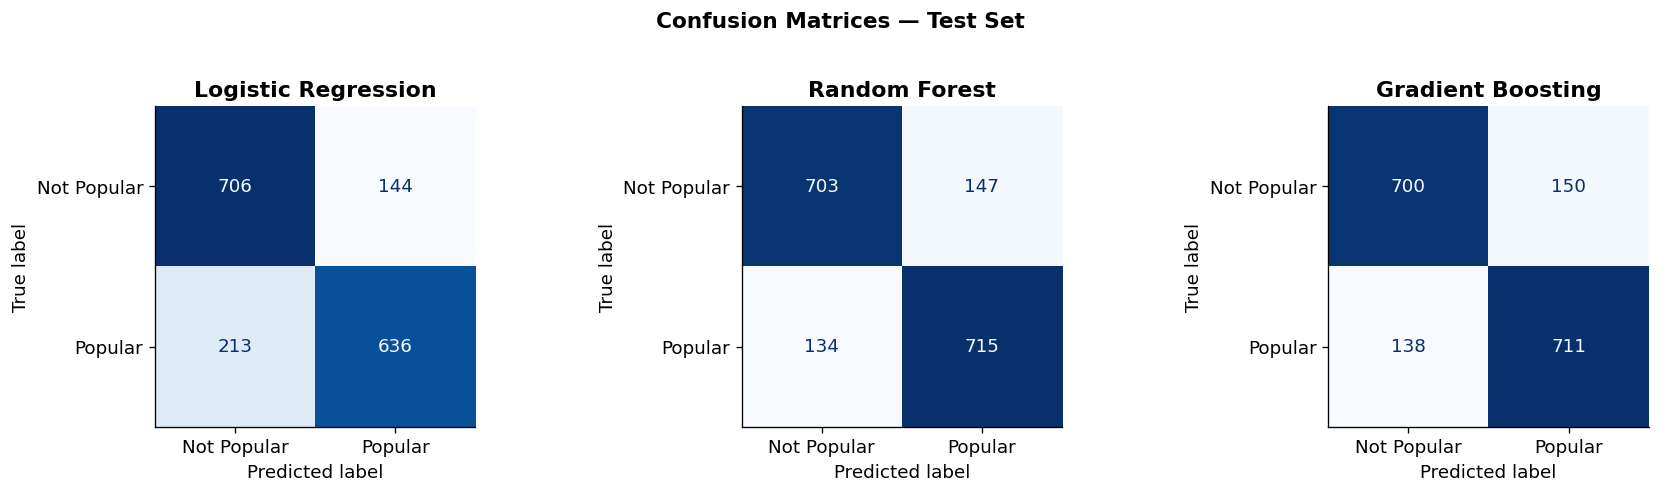

In [42]:
# ── Confusion matrices for all three models ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipeline) in zip(axes, trained_models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Popular','Popular'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [43]:
# ── Automatically select the best model ───────────────────────────────────────
# ROC AUC is used as the selection criterion because it measures discriminative ability
# independent of classification threshold, making it robust for a balanced binary problem.
best_model_name = results_df['ROC AUC'].idxmax()
best_pipeline   = trained_models[best_model_name]
best_metrics    = results_df.loc[best_model_name]

print(f'Best model: {best_model_name}')
print(best_metrics)

# Finding: Tree ensemble methods (Random Forest / Gradient Boosting) typically
# outperform Logistic Regression on this task because the relationship between
# product features and popularity involves non-linear interactions
# (e.g., a product must have both strong reviews AND strong brand presence to go viral).
print(f'\nFinding: {best_model_name} selected with ROC AUC = {best_metrics["ROC AUC"]:.4f}.')
print('Ensemble methods capture non-linear feature interactions that a linear model cannot.')

Best model: Random Forest
Accuracy     0.8346
Precision    0.8295
Recall       0.8422
F1 Score     0.8358
ROC AUC      0.9195
Name: Random Forest, dtype: float64

Finding: Random Forest selected with ROC AUC = 0.9195.
Ensemble methods capture non-linear feature interactions that a linear model cannot.


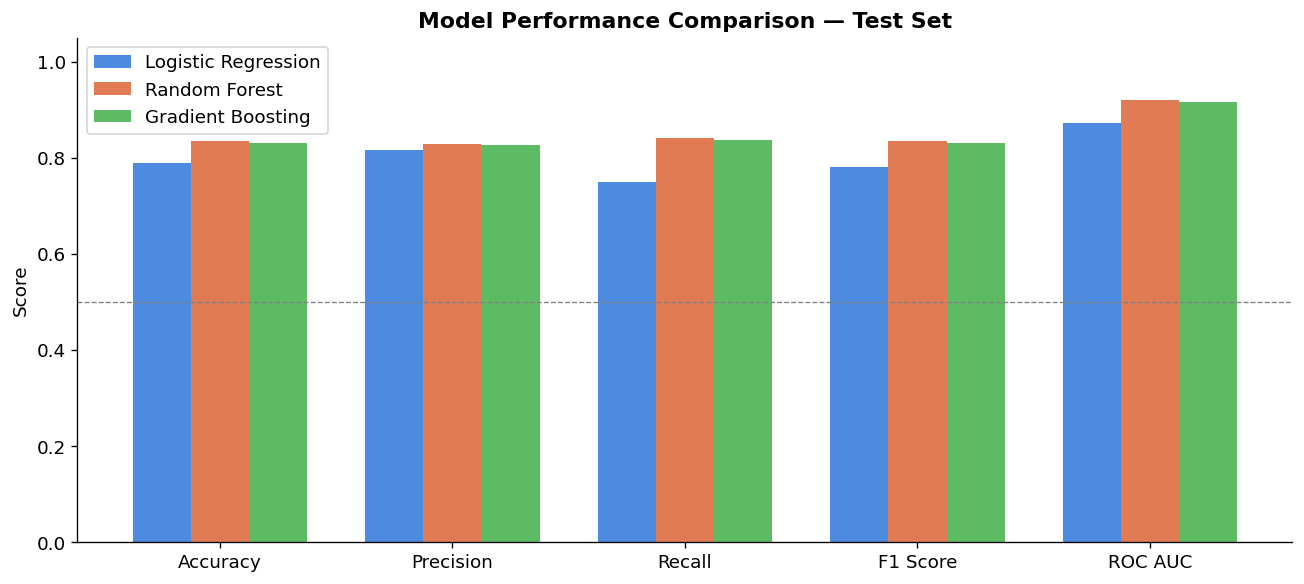

In [44]:
# ── Bar chart comparing all three models ─────────────────────────────────────
metrics_to_plot = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#4c8be0', '#e07b54', '#5dbb63']
for i, (name, _) in enumerate(trained_models.items()):
    vals = [results[name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i*width, vals, width, label=name, color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Test Set', fontweight='bold')
ax.legend()
ax.axhline(0.5, linestyle='--', color='grey', linewidth=0.8, label='Random baseline')
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 10. Feature Importance

In [45]:
best_preprocessor = best_pipeline.named_steps['preprocessor']
best_classifier   = best_pipeline.named_steps['classifier']

ohe_feature_names = (
    best_preprocessor
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols + ohe_feature_names

if hasattr(best_classifier, 'feature_importances_'):
    importances = best_classifier.feature_importances_
else:
    importances = np.abs(best_classifier.coef_[0])

feat_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

print('Top 15 Features:')
print(feat_imp_df.to_string(index=False))

Top 15 Features:
                feature  importance
 review_to_rating_ratio    0.169474
                reviews    0.153686
                 rating    0.068181
        child_min_price    0.048647
              price_usd    0.045575
           numeric_size    0.044817
        child_max_price    0.044634
            child_count    0.033341
       engagement_score    0.031601
            online_only    0.029170
     total_review_count    0.024000
primary_category_Makeup    0.014873
         verified_ratio    0.014856
   variation_type_Color    0.014497
          pct_five_star    0.012839


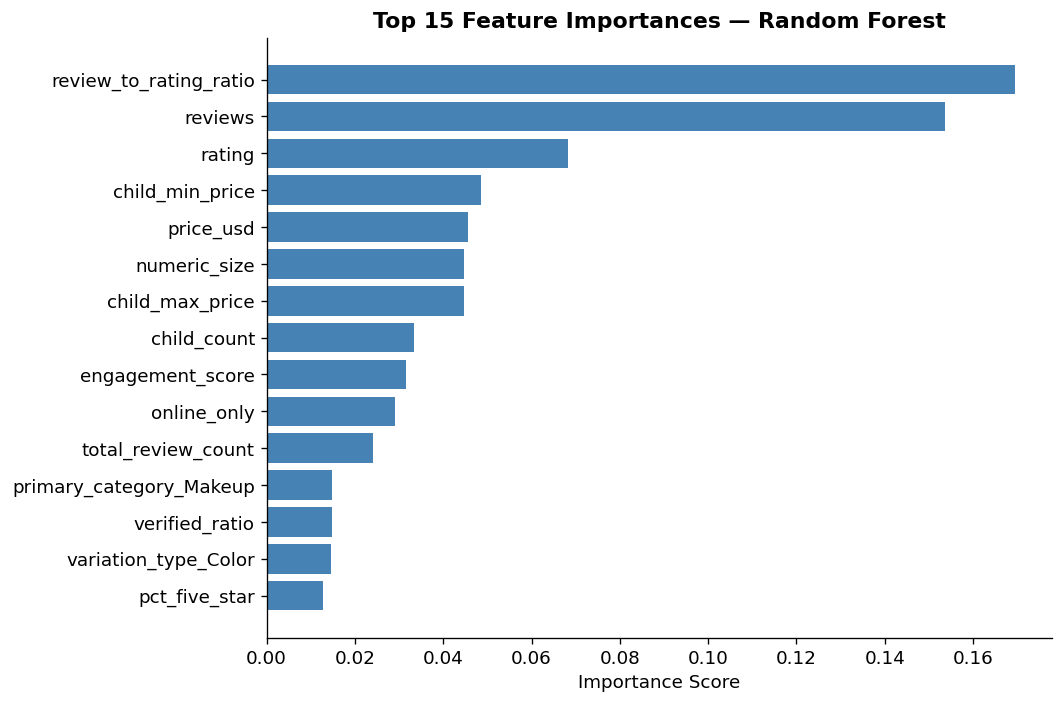

In [46]:
# ── Feature importance chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color='steelblue')
ax.set_title(f'Top 15 Feature Importances — {best_model_name}', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 11. Error Analysis

In [47]:
# Identify misclassified products in the test set and examine their characteristics.
y_pred_best = best_pipeline.predict(X_test)

# Reconstruct a test dataframe for interpretable error analysis
test_df = df.loc[X_test.index, [
    'product_name','brand_name','rating','reviews',
    'price_usd','loves_count','is_popular',
    'avg_review_score','total_review_count','pct_five_star'
]].copy()
test_df['predicted'] = y_pred_best
test_df['correct']   = (test_df['predicted'] == test_df['is_popular'])

misclassified = test_df[~test_df['correct']].copy()
print(f'Total misclassified: {len(misclassified)} out of {len(test_df)} test products')
print(f'Error rate: {len(misclassified)/len(test_df):.1%}')

Total misclassified: 281 out of 1699 test products
Error rate: 16.5%


In [48]:
# Show 5 representative misclassifications — sample both false positives and false negatives
false_positives = misclassified[misclassified['is_popular'] == 0].head(3)
false_negatives = misclassified[misclassified['is_popular'] == 1].head(2)
sample_errors   = pd.concat([false_positives, false_negatives])

display_cols = ['product_name','brand_name','is_popular','predicted',
                'rating','reviews','loves_count','avg_review_score','pct_five_star']
print('=== 5 Misclassified Products ===')
print(sample_errors[display_cols].to_string(index=False))

=== 5 Misclassified Products ===
                              product_name         brand_name  is_popular  predicted  rating  reviews  loves_count  avg_review_score  pct_five_star
       Regenerative Anti-Aging Moisturizer           Algenist           0          1  4.2715    221.0         6807          4.297674       0.688372
                           Mini Surf Spray  Bumble and bumble           0          1  3.1667     48.0         8787               NaN            NaN
       Translucent Pure Setting Spray 16HR      Laura Mercier           0          1  3.4408    574.0         3760               NaN            NaN
                            The Silk Cream             Tatcha           1          0  4.1885    260.0        44847          4.188462       0.634615
Mini Y Eau de Parfum & Eau de Toilette Set Yves Saint Laurent           1          0  4.7143      7.0        11111               NaN            NaN
